In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [4]:
BATCH_SIZE = 32
IMAGE_WIDTH = 256
IMAGE_HEIGHT = 192
CHANNELS = 3

In [6]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/datasets/ankityadavkaggle/dataset/SkinDisease',
    seed=99,
    shuffle=True,
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    crop_to_aspect_ratio = True,
    batch_size=BATCH_SIZE
)

Found 4267 files belonging to 4 classes.


In [7]:
len(dataset)

134

In [8]:
class_names = dataset.class_names
class_names

['Benign_tumors', 'Moles', 'Normal', 'SkinCancer']

In [9]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 192, 256, 3)
[2 0 2 0 0 2 2 2 2 2 2 2 2 0 2 3 2 0 0 2 3 2 2 2 2 1 2 2 2 0 0 0]


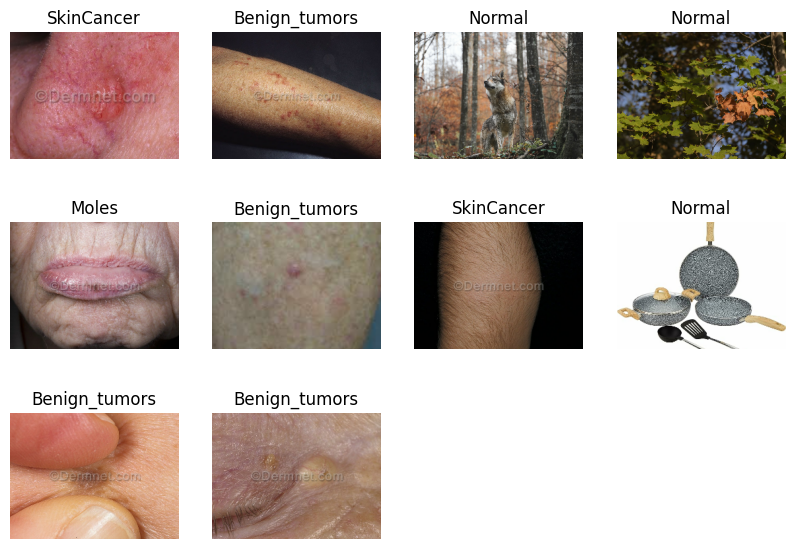

In [10]:
plt.figure(figsize=(10, 7))
for image_batch, labels_batch in dataset.take(1):
    for i in range(10):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")


In [11]:
for image_batch, label_batch in dataset.take(1):
    print(np.unique(label_batch, return_counts=True))

(array([0, 1, 2, 3], dtype=int32), array([14,  4, 11,  3]))


In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
len(dataset), len(train_ds), len(test_ds), len(val_ds)

(134, 107, 14, 13)

In [15]:
for x, y in dataset.take(1):
    print(x[1])
    print(y[:5])

tf.Tensor(
[[[143.84668  151.08789  110.08789 ]
  [132.34473  138.66211   94.66211 ]
  [ 98.68457  108.68457   56.68457 ]
  ...
  [147.00879  103.97754   68.91504 ]
  [125.1543    88.49805   56.279297]
  [146.66113  105.44238   70.44238 ]]

 [[170.40332  181.40332  138.40332 ]
  [109.62695  118.62695   71.96875 ]
  [ 76.993164  90.01758   37.01758 ]
  ...
  [149.88086  114.25586   82.78027 ]
  [141.11816  104.461914  72.243164]
  [159.60156  118.38281   83.38281 ]]

 [[138.49902  149.49902  107.10547 ]
  [147.50098  156.50098  111.07715 ]
  [108.94238  119.97461   64.12598 ]
  ...
  [ 60.59961   36.844727  12.87793 ]
  [155.66992  115.125     82.819336]
  [151.33691  113.555664  80.149414]]

 ...

 [[140.1875   111.        87.      ]
  [142.6875   112.25      86.46875 ]
  [162.03223  127.96973  102.93848 ]
  ...
  [148.21875  165.125    209.2168  ]
  [156.78809  162.46875  200.19434 ]
  [180.47559  181.8877   199.46289 ]]

 [[135.72363  106.53613   82.53613 ]
  [144.65625  114.21875   

In [16]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
from tensorflow.keras import layers
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_HEIGHT, IMAGE_WIDTH),
  layers.Rescaling(1./255),
])

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [20]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
input_shape = (IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS)
n_classes = 4

model = keras.Sequential([
    layers.Input(shape = input_shape),
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 192, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 190, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 95, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 93, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 12, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,620 (686.02 KB)

 Trainable params: 175,620 (686.02 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# model = tf.keras.models.load_model(
#    '/kaggle/input/models/ankityadavkaggle/model0/tensorflow2/default/1/0.keras',
#)

In [24]:
model.compile(
    optimizer = keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [26]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 492ms/step - accuracy: 0.4945 - loss: 1.1185 - val_accuracy: 0.6130 - val_loss: 0.9388
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 304ms/step - accuracy: 0.6005 - loss: 0.9187 - val_accuracy: 0.5938 - val_loss: 1.3324
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.6518 - loss: 0.8455 - val_accuracy: 0.6490 - val_loss: 0.8356
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 304ms/step - accuracy: 0.6365 - loss: 0.8529 - val_accuracy: 0.6226 - val_loss: 0.8237
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - accuracy: 0.6471 - loss: 0.8163 - val_accuracy: 0.6034 - val_loss: 0.8615
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 304ms/step - accuracy: 0.6630 - loss: 0.7700 - val_accuracy: 0.6370 - val_loss: 0.8243
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.6822 - loss: 0.7316 - val_accuracy: 0.6803 - val_loss: 0.7864
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.7104 - loss: 0

In [27]:
print("[INFO] Calculating model accuracy...")
scores = model.evaluate(test_ds)
print(f"Test Accuracy: {round(scores[1],4)*100}%")

[INFO] Calculating model accuracy...
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8252 - loss: 0.4558
Test Accuracy: 82.80999999999999%


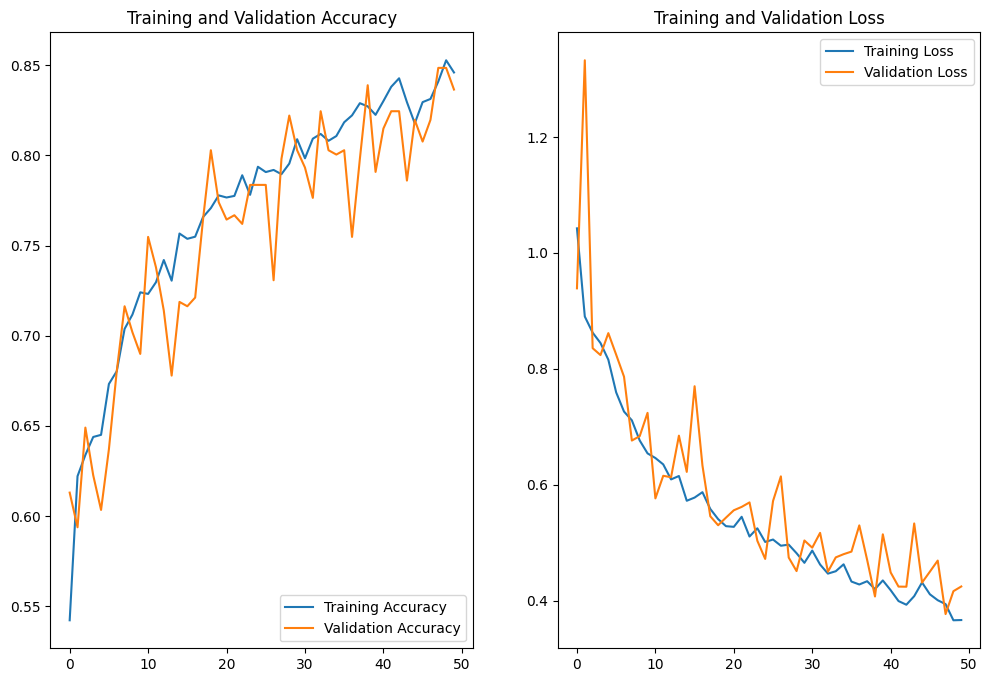

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(50)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [29]:
import os
os.makedirs("/kaggle/working/models", exist_ok=True)

In [32]:
model.save("/kaggle/working/models/3.keras")

In [33]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


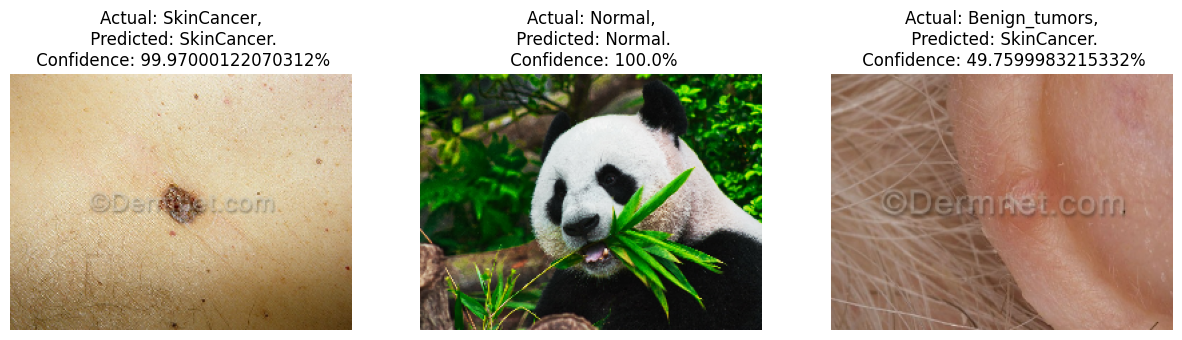

In [34]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(3):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        
        actual_class = class_names[labels[i]] 
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        plt.axis("off")